# Getting Started — CPI Gasoline Backtest

The bootcamp's **hello-world** forecasting experiment.  Run this notebook
top to bottom for an end-to-end tour of the evaluation framework on a
single, deliberately-hard target.

**Task.** Forecast Canada CPI Gasoline (index, 2002=100) exactly 1 month
ahead.  Evaluated at every monthly origin from 2000 to 2025, with a
held-out eval set covering Jan 2025 – Mar 2026.

**Why gasoline.** Because it *breaks* our models.  The series has four
textbook regime shifts in the evaluation window — the 2008 crude-oil
collapse, the 2014–16 OPEC-led decline, the 2020 COVID demand shock,
and the 2021–22 Russia/Ukraine surge.  That makes gasoline a good
motivator for everything downstream: exogenous covariates, LLM context,
agentic news retrieval.

**Why 1-month ahead.** StatCan publishes CPI ~3 weeks after the
reference month.  A forecast made at origin T resolves when the next
CPI print lands — short enough to run genuine **live / prospective**
tests as new data comes in month by month.

**Predictors.**

- `LastValuePredictor` — naive last-value baseline from `aieng.forecasting.methods.baselines.naive`.
  The performance floor every predictor must beat.
- `DartsAutoARIMAPredictor` — Darts `AutoARIMA` wrapped to emit
  probabilistic forecasts via Monte Carlo sampling.  Imported from
  `aieng.forecasting.methods.numerical.darts_arima`.

**Score.** Continuous Ranked Probability Score (CRPS, lower is better) — rewards both
calibration and sharpness.

**Prerequisites.**

```bash
uv run python scripts/fetch_cpi.py
```

In [1]:
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import yaml


ROOT = Path.cwd().resolve().parents[1]

## 1. Register CPI Gasoline

In [2]:
from aieng.forecasting.data import DataService, SeriesMetadata
from aieng.forecasting.data.adapters import StatCanAdapter


CPI_TABLE_ID = "18-10-0004-11"
CACHE_DIR = ROOT / "data" / "statcan"

svc = DataService()

gasoline_adapter = StatCanAdapter(
    table_id=CPI_TABLE_ID,
    member_filter={"GEO": "Canada", "Products and product groups": "Gasoline"},
    cache_dir=CACHE_DIR,
)
svc.register(
    "cpi_gasoline_canada",
    gasoline_adapter,
    SeriesMetadata(
        series_id="cpi_gasoline_canada",
        description="CPI Gasoline, Canada (2002=100)",
        source="StatCan table 18-10-0004-11",
        units="Index 2002=100",
        frequency="MS",
        table_id=CPI_TABLE_ID,
    ),
)

# Shelter is pre-registered too so the "try this next" cell at the end
# can re-run the backtest against a totally different inflation dynamic
# without any setup rerun.
shelter_adapter = StatCanAdapter(
    table_id=CPI_TABLE_ID,
    member_filter={"GEO": "Canada", "Products and product groups": "Shelter"},
    cache_dir=CACHE_DIR,
)
svc.register(
    "cpi_shelter_canada",
    shelter_adapter,
    SeriesMetadata(
        series_id="cpi_shelter_canada",
        description="CPI Shelter, Canada (2002=100)",
        source="StatCan table 18-10-0004-11",
        units="Index 2002=100",
        frequency="MS",
        table_id=CPI_TABLE_ID,
    ),
)

svc.summary()

,series_id,description,source,units,frequency,n_obs,start,end
0,cpi_gasoline_canada,"CPI Gasoline, Canada (2002=100)",StatCan table 18-10-0004-11,Index 2002=100,MS,926,1949-01-01,2026-02-01
1,cpi_shelter_canada,"CPI Shelter, Canada (2002=100)",StatCan table 18-10-0004-11,Index 2002=100,MS,570,1978-09-01,2026-02-01


## 2. Load the reference spec

In [3]:
from aieng.forecasting.evaluation import BacktestSpec


spec_path = ROOT / "reference_specs" / "cpi_gasoline_1m.yaml"
with spec_path.open() as f:
    spec = BacktestSpec.model_validate(yaml.safe_load(f))

origins = spec.origins()
print(f"Task:    {spec.task.task_id}")
print(f"Target:  {spec.task.target_series_id}")
print(f"Horizon: {spec.task.horizon} months")
print(f"Origins: {len(origins)} ({origins[0].date()} → {origins[-1].date()})")
print(f"Warmup:  {spec.warmup} observations")

Task:    cpi_gasoline_canada_12m
Target:  cpi_gasoline_canada
Horizon: 12 months
Origins: 53 (2000-01-01 → 2026-01-01)
Warmup:  24 observations


## 3. Define the predictors

- **`LastValuePredictor`** — `aieng.forecasting.methods.naive`.  No fitting required;
  predicts the last observed value at every quantile.  The floor.
- **`DartsAutoARIMAPredictor`** — `aieng.forecasting.methods.darts_arima`.  Wraps
  Darts `AutoARIMA` with Monte Carlo sampling for quantile
  estimates.  Univariate only.

Read `aieng-forecasting/aieng/forecasting/methods/naive.py` for an annotated reference on
how to satisfy the `Predictor` abstract base class when you write your own.

In [4]:
from aieng.forecasting.methods.numerical.darts_arima import DartsAutoARIMAPredictor
from aieng.forecasting.methods.baselines.naive import LastValuePredictor


naive_predictor = LastValuePredictor()
arima_predictor = DartsAutoARIMAPredictor(num_samples=500)
print(f"Predictors: {naive_predictor.predictor_id}, {arima_predictor.predictor_id}")

Predictors: last_value_naive, darts_autoarima


## 4. Run both backtests

The naive backtest is instant.  AutoARIMA fits once per origin — expect
a couple of minutes on a laptop.

In [5]:
from aieng.forecasting.evaluation import backtest


naive_results = backtest(predictor=naive_predictor, spec=spec, data_service=svc)
arima_results = backtest(predictor=arima_predictor, spec=spec, data_service=svc)

print(f"{'Predictor':<30} {'Origins':>8} {'Skipped':>8} {'Mean CRPS':>10}")
print("-" * 60)
for r in [naive_results, arima_results]:
    print(f"{r.predictor_id:<30} {len(r.predictions):>8} {r.skipped_origins:>8} {r.mean_crps:>10.4f}")

Predictor                       Origins  Skipped  Mean CRPS
------------------------------------------------------------
last_value_naive                     51        2    21.4863
darts_autoarima                      51        2    16.8246


## 5. Per-origin CRPS comparison

Mean CRPS is a single number; the per-origin breakdown tells the
actual story.

In [6]:
def result_to_df(result, label):
    return pd.DataFrame(
        {
            "origin": [p.as_of.date() for p in result.predictions],
            "forecast_date": [p.forecast_date.date() for p in result.predictions],
            f"point_{label}": [p.payload.point_forecast for p in result.predictions],
            f"crps_{label}": result.scores,
        }
    ).set_index("forecast_date")


naive_df = result_to_df(naive_results, "naive")
arima_df = result_to_df(arima_results, "arima")

comparison = naive_df.join(arima_df[["point_arima", "crps_arima"]], how="inner")
comparison["crps_reduction"] = comparison["crps_naive"] - comparison["crps_arima"]

print(f"Mean CRPS  naive:  {comparison['crps_naive'].mean():.4f}")
print(f"Mean CRPS  arima:  {comparison['crps_arima'].mean():.4f}")
print(
    f"Mean reduction:    {comparison['crps_reduction'].mean():.4f}"
    f"  ({comparison['crps_reduction'].mean() / comparison['crps_naive'].mean() * 100:.1f}%)"
)
comparison.reset_index().head(10)

Mean CRPS  naive:  21.4863
Mean CRPS  arima:  16.8246
Mean reduction:    4.6617  (21.7%)


,forecast_date,origin,point_naive,crps_naive,point_arima,crps_arima,crps_reduction
0,2001-01-01,2000-01-01,93.9,9.2,95.829341,4.314815,4.885185
1,2001-07-01,2000-07-01,107.1,9.5,109.987379,9.015356,0.484644
2,2002-01-01,2001-01-01,104.8,18.1,106.575695,16.869740,1.230260
3,2002-07-01,2001-07-01,108.0,5.5,108.835414,3.957633,1.542367
4,2003-01-01,2002-01-01,84.5,23.9,86.612352,18.533555,5.366445
5,2003-07-01,2002-07-01,99.7,2.7,101.856957,1.539157,1.160843
6,2004-01-01,2003-01-01,102.2,3.6,103.860739,1.748352,1.851648
7,2004-07-01,2003-07-01,100.5,20.2,104.271811,13.040764,7.159236
8,2005-01-01,2004-01-01,100.0,14.9,103.222937,8.530030,6.369970
9,2005-07-01,2004-07-01,125.1,10.4,122.230334,9.512612,0.887388


## 6. Predictions vs. actuals — the visual story

One chart, last ~16 years of data, with AutoARIMA's 80% CI shaded so the
model's uncertainty (and its collapses) are visible next to the observed
series.  A companion panel underneath shows per-origin CRPS over time —
the spikes line up with the regime shifts.

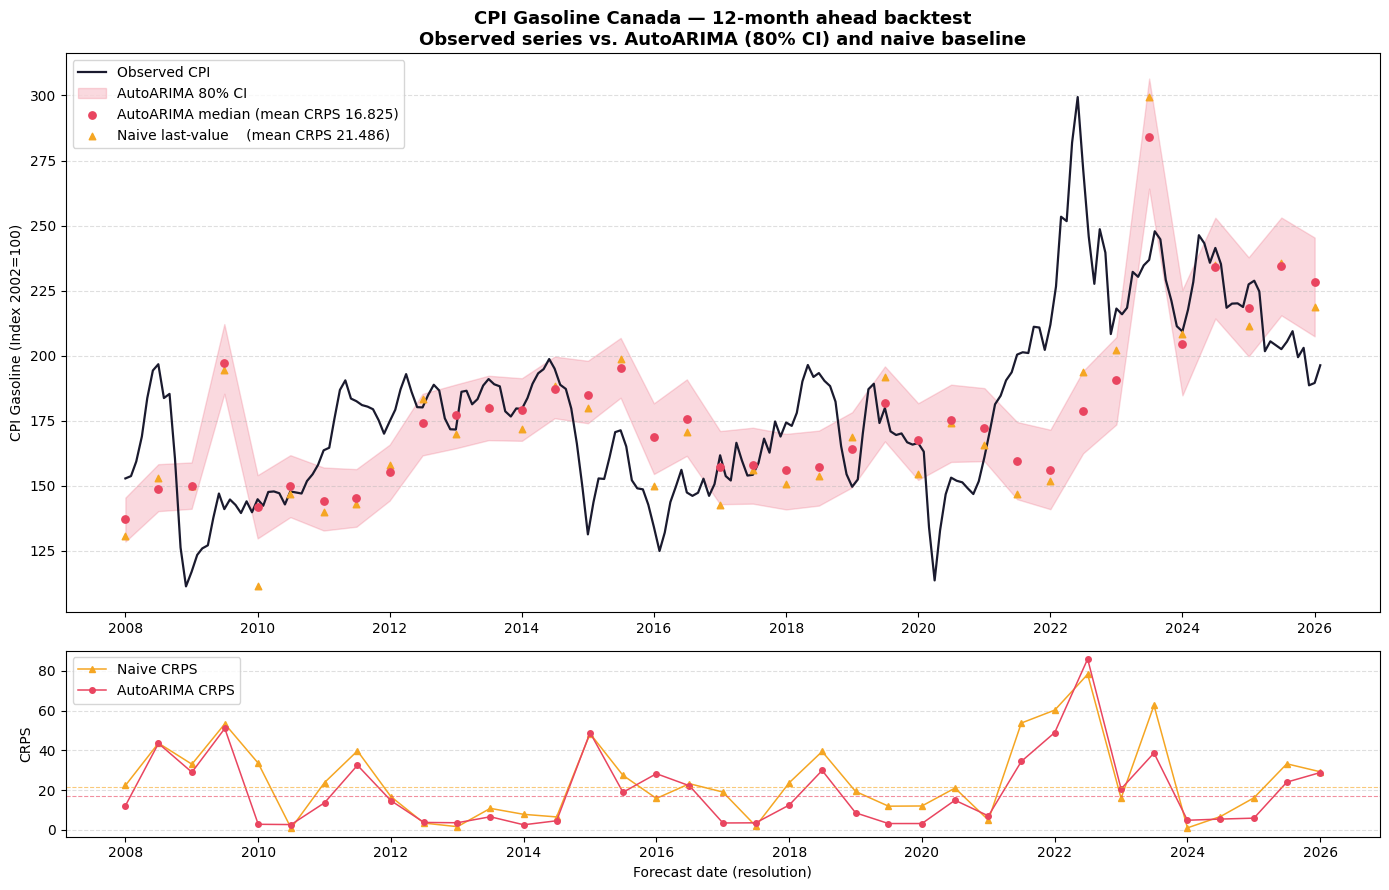

In [7]:
COLOR_OBS = "#1a1a2e"
COLOR_ARIMA = "#e94560"
COLOR_NAIVE = "#f5a623"

full_series = svc.get_series(
    "cpi_gasoline_canada",
    as_of=datetime.now(tz=timezone.utc).replace(tzinfo=None),
)
PLOT_START = pd.Timestamp("2008-01-01")
plot_series = full_series[full_series["timestamp"] >= PLOT_START]

arima_dates = [p.forecast_date for p in arima_results.predictions]
arima_points = [p.payload.point_forecast for p in arima_results.predictions]
arima_q10 = [p.payload.quantiles.get(0.10, p.payload.point_forecast) for p in arima_results.predictions]
arima_q90 = [p.payload.quantiles.get(0.90, p.payload.point_forecast) for p in arima_results.predictions]

naive_dates = [p.forecast_date for p in naive_results.predictions]
naive_points = [p.payload.point_forecast for p in naive_results.predictions]

# Trim plotted predictions to the visible window.
arima_mask = [d >= PLOT_START.to_pydatetime() for d in arima_dates]
arima_dates_p = [d for d, keep in zip(arima_dates, arima_mask) if keep]
arima_points_p = [v for v, keep in zip(arima_points, arima_mask) if keep]
arima_q10_p = [v for v, keep in zip(arima_q10, arima_mask) if keep]
arima_q90_p = [v for v, keep in zip(arima_q90, arima_mask) if keep]
arima_scores_p = [s for s, keep in zip(arima_results.scores, arima_mask) if keep]

naive_mask = [d >= PLOT_START.to_pydatetime() for d in naive_dates]
naive_dates_p = [d for d, keep in zip(naive_dates, naive_mask) if keep]
naive_points_p = [v for v, keep in zip(naive_points, naive_mask) if keep]
naive_scores_p = [s for s, keep in zip(naive_results.scores, naive_mask) if keep]

fig, axes = plt.subplots(2, 1, figsize=(14, 9), gridspec_kw={"height_ratios": [3, 1]})

ax = axes[0]
ax.plot(plot_series["timestamp"], plot_series["value"], color=COLOR_OBS, linewidth=1.6, label="Observed CPI")
ax.fill_between(arima_dates_p, arima_q10_p, arima_q90_p, alpha=0.20, color=COLOR_ARIMA, label="AutoARIMA 80% CI")
ax.scatter(
    arima_dates_p,
    arima_points_p,
    color=COLOR_ARIMA,
    s=28,
    zorder=5,
    label=f"AutoARIMA median (mean CRPS {arima_results.mean_crps:.3f})",
)
ax.scatter(
    naive_dates_p,
    naive_points_p,
    color=COLOR_NAIVE,
    s=22,
    marker="^",
    zorder=4,
    label=f"Naive last-value    (mean CRPS {naive_results.mean_crps:.3f})",
)
ax.set_title(
    "CPI Gasoline Canada — 12-month ahead backtest\nObserved series vs. AutoARIMA (80% CI) and naive baseline",
    fontsize=13,
    fontweight="bold",
)
ax.set_ylabel("CPI Gasoline (Index 2002=100)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.legend(loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.4)

ax2 = axes[1]
ax2.plot(naive_dates_p, naive_scores_p, color=COLOR_NAIVE, linewidth=1.1, marker="^", markersize=4, label="Naive CRPS")
ax2.plot(
    arima_dates_p, arima_scores_p, color=COLOR_ARIMA, linewidth=1.1, marker="o", markersize=4, label="AutoARIMA CRPS"
)
ax2.axhline(naive_results.mean_crps, color=COLOR_NAIVE, linestyle="--", linewidth=0.8, alpha=0.6)
ax2.axhline(arima_results.mean_crps, color=COLOR_ARIMA, linestyle="--", linewidth=0.8, alpha=0.6)
ax2.set_ylabel("CRPS")
ax2.set_xlabel("Forecast date (resolution)")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.xaxis.set_major_locator(mdates.YearLocator(2))
ax2.legend(loc="upper left")
ax2.grid(axis="y", linestyle="--", alpha=0.4)

fig.tight_layout()
plt.show()

## 7. Where does it fail?

Sort the per-origin table by AutoARIMA CRPS to see the worst cases.
These are not random outliers — they line up one-for-one with the
macro regime shifts a 12-month-ahead model has no way to see coming.

| Forecast year | Real-world context |
|---|---|
| 2009 | Crude oil collapsed ~70% from its July 2008 peak — 2008 origins project into the trough. |
| 2015–16 | OPEC-led oil price decline; Saudi market-share strategy. |
| 2020–21 | COVID-19 demand shock, then the reopening surge. |
| 2022–23 | Russian invasion of Ukraine drove a global oil shock. |

This table is exactly the motivation for richer methods: exogenous
covariates (FRED crude oil, CAD/USD), LLM context (news, policy), or
agents that can retrieve that context themselves.

In [8]:
worst = comparison.sort_values("crps_arima", ascending=False).head(8)
worst_display = worst.reset_index().assign(
    origin=lambda df: df["origin"].astype(str),
    forecast_date=lambda df: df["forecast_date"].astype(str),
)[["origin", "forecast_date", "point_naive", "point_arima", "crps_naive", "crps_arima"]]
worst_display

,origin,forecast_date,point_naive,point_arima,crps_naive,crps_arima
0,2021-07-01,2022-07-01,193.6,178.876755,78.2,85.914934
1,2008-07-01,2009-07-01,194.3,197.064581,53.3,50.990719
2,2021-01-01,2022-01-01,151.7,155.899666,60.2,48.935774
3,2014-01-01,2015-01-01,179.7,185.004212,48.4,48.875415
4,2007-07-01,2008-07-01,153.1,148.834518,43.6,43.466915
5,2022-07-01,2023-07-01,299.4,284.216327,62.6,38.643544
6,2020-07-01,2021-07-01,146.7,159.348413,53.7,34.408303
7,2010-07-01,2011-07-01,142.8,145.230847,39.7,32.480186


## 8. Spend an eval run (optional)

`evaluate()` is the counterpart to `backtest()`.  It runs against the
held-out eval window (`reference_specs/cpi_gasoline_eval_2025.yaml`,
covering Jan 2025 – Mar 2026) and decrements a per-participant budget
tracked in `data/eval_runs.yaml` (gitignored).  `max_runs: 5` means
each participant may spend at most five runs against this spec — that
deliberate scarcity is what makes the eval number a real generalisation
estimate rather than another metric to over-fit.

Because h=1 and StatCan releases CPI monthly, all origins in this eval
window are already resolved and the results are fully interpretable.
This is also the window that will grow over time as new monthly CPI
prints land — it is the natural bridge to live forecasting.

The cell below is **commented out** to protect the budget.  Uncomment
and run it once you have a predictor you're confident about.

```python
from aieng.forecasting.evaluation import EvalSpec, EvalTracker, evaluate

eval_spec_path = ROOT / "reference_specs" / "cpi_gasoline_eval_2025.yaml"
with eval_spec_path.open() as f:
    eval_spec = EvalSpec.model_validate(yaml.safe_load(f))

tracker = EvalTracker(ROOT / "data" / "eval_runs.yaml")
eval_result = evaluate(
    predictor=arima_predictor,
    spec=eval_spec,
    data_service=svc,
    tracker=tracker,
)
print(
    f"Eval mean CRPS: {eval_result.mean_crps:.4f}  "
    f"(run {eval_result.run_number}/{eval_spec.max_runs})"
)
```

## 9. Try this next: re-run against Shelter

Shelter tells the opposite story to gasoline: sticky trend, low
month-to-month volatility, one large regime shift (2021–24) driven by
housing and monetary policy.  AutoARIMA should do relatively well on
the stationary portion and miss the shift — a different failure mode
from gasoline's.

The cell below constructs a spec variant in Python against the
already-registered `cpi_shelter_canada` series.  For a more persistent
configuration, copy `reference_specs/cpi_gasoline_12m.yaml` to
`reference_specs/cpi_shelter_12m.yaml` and swap the series ID.

After that, the natural graduation step is
`implementations/food_price_forecasting/` — nine correlated
series, a 12-step trajectory, and the avg/avg YoY metric that
Canada's Food Price Report actually publishes.

In [9]:
from aieng.forecasting.evaluation import ForecastingTask


shelter_spec = BacktestSpec(
    task=ForecastingTask(
        task_id="cpi_shelter_canada_1m",
        target_series_id="cpi_shelter_canada",
        horizons=[1],
        frequency="MS",
        description="CPI Shelter Canada, 1-month ahead forecast.",
    ),
    start=spec.start,
    end=spec.end,
    stride=spec.stride,
    warmup=spec.warmup,
    description="Shelter variant of the getting-started spec — the gasoline foil.",
)

naive_shelter = backtest(predictor=naive_predictor, spec=shelter_spec, data_service=svc)
arima_shelter = backtest(predictor=arima_predictor, spec=shelter_spec, data_service=svc)

print(f"{'Target':<20} {'Predictor':<20} {'Mean CRPS':>10}")
print("-" * 55)
print(f"{'Gasoline':<20} {'Naive':<20} {naive_results.mean_crps:>10.3f}")
print(f"{'Gasoline':<20} {'AutoARIMA':<20} {arima_results.mean_crps:>10.3f}")
print(f"{'Shelter':<20} {'Naive':<20} {naive_shelter.mean_crps:>10.3f}")
print(f"{'Shelter':<20} {'AutoARIMA':<20} {arima_shelter.mean_crps:>10.3f}")

Target               Predictor             Mean CRPS
-------------------------------------------------------
Gasoline             Naive                    21.486
Gasoline             AutoARIMA                16.825
Shelter              Naive                     4.192
Shelter              AutoARIMA                 1.678


## 10. Serialize the result to YAML

`BacktestResult` is a Pydantic model — serialisable to YAML alongside
the predictor implementation, passable to a downstream agent as
structured context, or usable as a submission artefact in a future
leaderboard mechanism.

In [10]:
result_dict = arima_results.model_dump(mode="json")
result_yaml = yaml.dump(result_dict, default_flow_style=False, allow_unicode=True)

print("\n".join(result_yaml.splitlines()[:35]))
print("...")

mean_crps: 16.82461877126854
predictions:
- as_of: '2000-01-01T00:00:00'
  forecast_date: '2001-01-01T00:00:00'
  issued_at: '2026-05-20T17:43:01.696977'
  metadata: {}
  payload:
    point_forecast: 95.82934107992506
    quantiles:
      '0.05': 87.66412233064356
      '0.1': 89.3678687195938
      '0.2': 91.6150905071952
      '0.3': 93.10921550501281
      '0.4': 94.45240797565498
      '0.5': 95.82934107992506
      '0.6': 97.73909275549933
      '0.7': 99.13214563183621
      '0.8': 100.85662239784104
      '0.9': 102.5022798212941
      '0.95': 104.69098200691037
  predictor_id: darts_autoarima
  task_id: cpi_gasoline_canada_12m
- as_of: '2000-07-01T00:00:00'
  forecast_date: '2001-07-01T00:00:00'
  issued_at: '2026-05-20T17:43:01.765487'
  metadata: {}
  payload:
    point_forecast: 109.987378748451
    quantiles:
      '0.05': 101.2090619405171
      '0.1': 102.65919999633657
      '0.2': 104.67219874350968
      '0.3': 106.35790680159477
      '0.4': 108.02021845403993
      '